# ⚙️ Day 49 — Feature Engineering II
**Month 3 · Week 4 · Python + Pandas**

---

> **Scenario — ShopEase Analytics:**
> The ML team has your cleaned dataset and says:
> *"Raw columns alone won't cut it. We need time-based signals,
> encoded categories, ratio features, and meaningful bins before
> we can train anything useful. Engineer the features."*
>
> Day 45 gave you the basics (derived columns, flag columns, simple arithmetic).
> Day 49 gives you the professional toolkit:
> **time features → encoding → ratio features → binning → interaction features.**


---
## 📦 Section 1 — Raw Data
*Do NOT modify this cell. All work happens in Section 3.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Raw ShopEase dataset with datetime column ─────────────────────────────────
np.random.seed(42)
n = 300

regions    = np.random.choice(['North','South','East','West'], n, p=[0.35,0.25,0.25,0.15])
categories = np.random.choice(['Electronics','Clothing','Groceries','Furniture'], n,
                               p=[0.30,0.30,0.25,0.15])
quantities = np.random.randint(1, 15, n)

base_rev   = np.random.exponential(scale=150, size=n)
region_mult  = {'North':1.3,'South':1.0,'East':1.1,'West':0.85}
cat_mult     = {'Electronics':1.8,'Clothing':1.0,'Groceries':0.7,'Furniture':2.2}

revenue = np.array([
    base_rev[i] * region_mult[regions[i]] * cat_mult[categories[i]]
    * (0.9 + 0.2*np.random.random())
    for i in range(n)
]).round(2)

discount      = np.random.choice([0,5,10,15,20], n, p=[0.4,0.25,0.2,0.1,0.05])
customer_age  = np.random.randint(18, 65, n)
is_member     = np.random.choice([0, 1], n, p=[0.4, 0.6])

# Date range: Jan 2023 – Dec 2023
order_dates = pd.date_range('2023-01-01', periods=n, freq='D').to_series().sample(n, random_state=42).values

df_raw = pd.DataFrame({
    'order_id'    : [f'ORD-{1000+i}' for i in range(n)],
    'order_date'  : order_dates,
    'region'      : regions,
    'category'    : categories,
    'quantity'    : quantities,
    'revenue'     : revenue,
    'discount'    : discount,
    'customer_age': customer_age,
    'is_member'   : is_member,
})

print("Shape:", df_raw.shape)
print("Dtypes:\n", df_raw.dtypes)
df_raw.head()


Shape: (300, 9)
Dtypes:
 order_id                object
order_date      datetime64[ns]
region                  object
category                object
quantity                 int32
revenue                float64
discount                 int64
customer_age             int32
is_member                int64
dtype: object


,order_id,order_date,region,category,quantity,revenue,discount,customer_age,is_member
0,ORD-1000,2023-07-23,South,Electronics,5,109.76,0,59,1
1,ORD-1001,2023-09-24,West,Clothing,2,210.19,0,55,1
2,ORD-1002,2023-06-02,East,Clothing,12,18.56,20,35,0
3,ORD-1003,2023-01-10,South,Groceries,10,186.26,0,62,0
4,ORD-1004,2023-08-22,North,Groceries,13,16.91,15,52,1


---
## 📖 Section 2 — Concept Notes

### Why Feature Engineering matters for ML

Raw columns are what happened. Engineered features are **what the model needs to understand why it happened.**

A model can't learn from `order_date = 2023-12-24` directly.
But it can learn from `is_weekend = 1`, `month = 12`, `quarter = 4`, `is_holiday_season = 1`.

The quality of your features determines the ceiling of your model's performance — more than the algorithm choice.

---

### 1️⃣ Time-Based Features
Extract meaningful signals from a datetime column.

```python
df['order_date'] = pd.to_datetime(df['order_date'])

df['month']       = df['order_date'].dt.month        # 1–12
df['quarter']     = df['order_date'].dt.quarter      # 1–4
df['day_of_week'] = df['order_date'].dt.dayofweek    # 0=Mon, 6=Sun
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['week_of_year']= df['order_date'].dt.isocalendar().week.astype(int)
```

**Why:** Sales patterns repeat on weekly and monthly cycles. A model with `month` as a feature can learn "December always spikes." Without it, it's blind.

---

### 2️⃣ Label Encoding vs One-Hot Encoding

**Label Encoding** — assign an integer to each category.
```python
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['region'])
# North=2, South=3, East=0, West=4 (alphabetical order)
```
⚠️ Problem: the model sees North(2) > East(0), implying an order that doesn't exist.
Use only for **ordinal** categories (Low < Medium < High).

**One-Hot Encoding** — create a binary column per category.
```python
dummies = pd.get_dummies(df['category'], prefix='cat', drop_first=True)
df = pd.concat([df, dummies], axis=1)
```
`drop_first=True` drops one column to avoid multicollinearity (dummy variable trap).
Use for **nominal** categories (no natural order) like region, category.

**Manual mapping** — when you control the order:
```python
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
df['size_encoded'] = df['size'].map(size_map)
```

---

### 3️⃣ Ratio Features
Combine two columns to create a rate or proportion that carries more signal than either alone.

```python
df['revenue_per_unit']   = df['revenue'] / df['quantity']     # average unit price
df['discount_rate']      = df['discount'] / 100               # as a proportion
df['discounted_revenue'] = df['revenue'] * (1 - df['discount_rate'])
```

**Why:** `revenue = 500` and `quantity = 10` individually tell you less than `revenue_per_unit = 50` (average unit price). The ratio is the signal.

**Watch out for division by zero:**
```python
df['revenue_per_unit'] = df['revenue'] / df['quantity'].replace(0, np.nan)
```

---

### 4️⃣ Binning (Discretisation)
Convert a continuous variable into meaningful groups.

**Equal-width bins (pd.cut)** — each bin covers the same value range:
```python
df['revenue_band'] = pd.cut(df['revenue'],
                             bins=3,
                             labels=['Low', 'Medium', 'High'])
```

**Equal-frequency bins (pd.qcut)** — each bin has the same number of rows:
```python
df['revenue_quartile'] = pd.qcut(df['revenue'],
                                  q=4,
                                  labels=['Q1','Q2','Q3','Q4'])
```

**Custom bins** — you define the boundaries:
```python
df['age_group'] = pd.cut(df['customer_age'],
                          bins=[0, 25, 40, 55, 100],
                          labels=['Young','Mid','Senior','Elder'])
```

**pd.cut vs pd.qcut:**
- `pd.cut` → equal range, unequal counts (skewed data = empty bins risk)
- `pd.qcut` → equal counts, unequal range (handles skew better)

---

### 5️⃣ Interaction Features
Multiply or combine two features to capture a joint signal.

```python
df['qty_x_discount']     = df['quantity'] * df['discount']
df['member_x_revenue']   = df['is_member'] * df['revenue']
```

**Why:** Maybe members AND high revenue together predict churn — but neither alone does. The interaction term lets the model see the combination.

---

### 6️⃣ Feature Summary Table
Always end feature engineering with a summary:

```python
new_features = ['month', 'quarter', 'is_weekend', 'revenue_per_unit',
                'revenue_band', 'age_group', 'qty_x_discount']
df[new_features].describe()
```

This catches: unexpected nulls, impossible values, zero-variance columns (useless for ML).


---
## ✏️ Section 3 — Practice Tasks

**Rules:**
1. Start every task with `df = df_raw.copy()`
2. Never modify `df_raw`
3. Written interpretations: **Number + Reason + Action** format
4. All new columns must use snake_case names


---
### 🔵 Task A — Time-Based Features (20 pts)

**A1 (10 pts) — Extract 5 time features**
- Copy `df_raw` → `df`
- Convert `order_date` to datetime
- Create these 5 columns:
  - `month` (1–12)
  - `quarter` (1–4)
  - `day_of_week` (0=Mon, 6=Sun)
  - `is_weekend` (1 if Sat/Sun, else 0) — integer dtype
  - `week_of_year` (ISO week number)
- Print `df[['order_date','month','quarter','day_of_week','is_weekend','week_of_year']].head(8)`

**A2 (10 pts) — Monthly revenue bar chart + insight**
- Group by `month`, sum `revenue`
- Bar chart: x=month (1–12), y=total revenue, color `#1F3864`
- Add a horizontal line for the monthly average (red dashed, labelled)
- Insight title: which month peaks + what that means for inventory
- Save as `A2_monthly_revenue.png`
- In markdown below: 2-sentence interpretation (Number + Reason + Action)


In [2]:
# A1 — Time-based features
df = df_raw.copy()

# convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# create month, quarter, day_of_week, is_weekend, week_of_year
df['month']           = df['order_date'].dt.month
df['quarter']         = df['order_date'].dt.quarter
df['day_of_week']     = df['order_date'].dt.dayofweek
df['is_weekend']      = df['day_of_week'].isin([5,6]).astype(int)
df['week_of_year']    = df['order_date'].dt.isocalendar().week.astype(int)

# print the 6 columns for first 8 rows
print(df[['order_date', 'month', 'quarter', 'day_of_week', 'is_weekend', 'week_of_year']].head(8))

  order_date  month  quarter  day_of_week  is_weekend  week_of_year
0 2023-07-23      7        3            6           1            29
1 2023-09-24      9        3            6           1            38
2 2023-06-02      6        2            4           0            22
3 2023-01-10      1        1            1           0             2
4 2023-08-22      8        3            1           0            34
5 2023-08-15      8        3            1           0            33
6 2023-07-16      7        3            6           1            28
7 2023-04-20      4        2            3           0            16


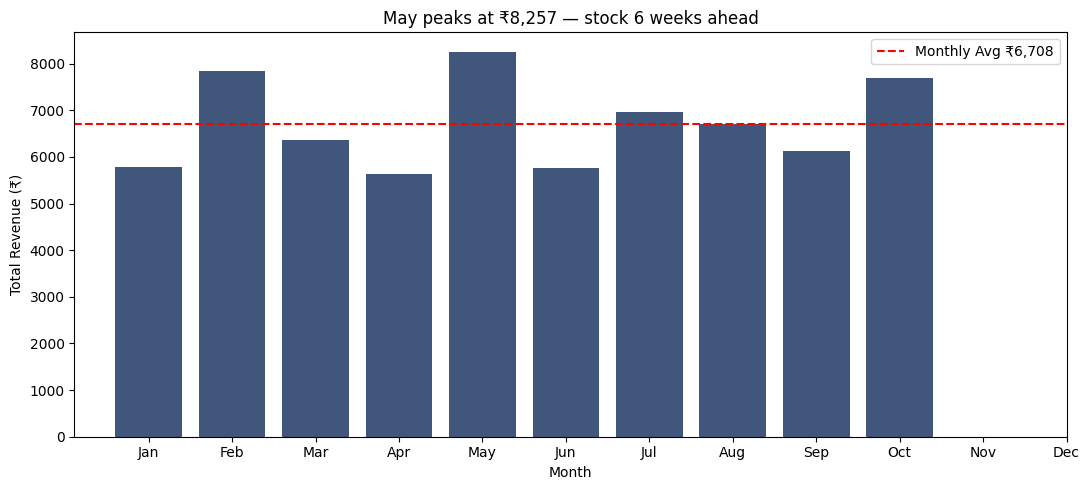

month
1     5778.09
2     7831.97
3     6352.89
4     5640.09
5     8257.03
6     5759.18
7     6956.62
8     6696.61
9     6123.78
10    7682.01
Name: revenue, dtype: float64


In [23]:
# A2 — Monthly revenue bar chart
df = df_raw.copy()

# convert date and create month column
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month

# group by month, sum revenue
monthly = df.groupby('month')['revenue'].sum()
avg = monthly.mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(11, 5))
peak_month = monthly.idxmax()                    
peak_revenue = monthly.max()                       
peak_name = month_names[peak_month - 1] 
# bar chart
bars = ax.bar(monthly.index, monthly.values, color = '#1F3864', alpha=0.85)

# horizontal average line (red dashed, labelled)
ax.axhline(avg, color='red', linestyle='--', linewidth=1.5, label=f'Monthly Avg ₹{avg:,.0f}')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (₹)')
ax.set_title(f'{peak_name} peaks at ₹{peak_revenue:,.0f} — stock 6 weeks ahead')
ax.legend()
plt.tight_layout()
plt.savefig('A2_monthly_revenue.png', dpi=150)
plt.show()
print(monthly)

**A2 Interpretation (Number + Reason + Action):**

Number: Revenue peaks in May at approximately ₹8,257, significantly exceeding the monthly average of ₹6,708.

Reason: This surge likely indicates a seasonal demand peak, while the secondary spikes in February and October suggest quarterly promotional cycles or holiday shopping behavior.

Action: We should initiate stock procurement for high-value categories like Electronics and Furniture at least 6 weeks ahead of May to ensure availability and optimize logistics costs before the peak period.


---
### 🟢 Task B — Encoding (20 pts)

**B1 (8 pts) — One-hot encode `category`**
- Copy `df_raw` → `df`
- Use `pd.get_dummies(df['category'], prefix='cat', drop_first=True)`
- Concatenate dummies to `df`
- Print shape before and after
- Print the new dummy column names
- Print first 5 rows of dummy columns only

**B2 (7 pts) — Label encode `region` manually**
- Create `region_encoded` using a dictionary map:
  `{'North': 3, 'South': 2, 'East': 1, 'West': 0}`
  (ordered by average revenue — North highest, West lowest)
- Print `df[['region','region_encoded']].drop_duplicates().sort_values('region_encoded')`

**B3 (5 pts) — Why one-hot for category but manual map for region?**
- Answer in the markdown cell below (2–3 sentences)
- Mention: ordinal vs nominal, dummy variable trap, multicollinearity


In [4]:
# B1 — One-hot encode category
df = df_raw.copy()

# print shape before
print('Shape before:', df.shape)

# create dummies and concatenate
dummies = pd.get_dummies(df['category'], prefix='cat', drop_first=True)
df = pd.concat([df, dummies], axis=1)

# print shape after, dummy column names, first 5 rows of dummy cols
print('Shape after:', df.shape)
print('New dummy columns:', list(dummies.columns))
print(df[list(dummies.columns)].head())

Shape before: (300, 9)
Shape after: (300, 12)
New dummy columns: ['cat_Electronics', 'cat_Furniture', 'cat_Groceries']
   cat_Electronics  cat_Furniture  cat_Groceries
0             True          False          False
1            False          False          False
2            False          False          False
3            False          False           True
4            False          False           True


In [5]:
# B2 — Label encode region with manual map
df = df_raw.copy()

# define the map (North=3 highest revenue, West=0 lowest)
region_map = {'North': 3, 'South': 2, 'East': 1, 'West': 0}

# apply map
df['region_encoded'] = df['region'].map(region_map)

# print unique region-encoding pairs sorted
print(df[['region', 'region_encoded']].drop_duplicates().sort_values('region_encoded'))

  region  region_encoded
1   West               0
2   East               1
0  South               2
4  North               3


**B3 — Why different encoding for each? (2–3 sentences):**

*Category uses One-Hot Encoding because it is a nominal variable with no inherent order; by using drop_first=True, we create n−1 dummy variables to avoid the dummy variable trap and prevent multicollinearity in future modeling. In contrast, Region is treated as an ordinal variable because the manual map (0−3) assigns a specific rank based on revenue performance, allowing the model to capture the mathematical trend between geographic areas. This dual approach ensures that the model respects the natural structure of the data while maintaining statistical integrity by preventing redundant feature information.*


`category` (Electronics, Clothing, Groceries, Furniture) is **nominal** — there is no natural ordering between these labels. Assigning integers (0,1,2,3) would imply Electronics < Clothing < Groceries < Furniture, which is false and would mislead the model. One-hot encoding creates independent binary columns so the model treats each category independently, with `drop_first=True` removing one column to avoid the dummy variable trap (perfect multicollinearity — if the other 3 dummies are all 0, the dropped category is implied).

`region` receives a manual ordinal map because we have external business knowledge that the regions rank by revenue (North > South > East > West). This is a domain-informed encoding, not random — so the integer order is meaningful and a regression model can learn from it correctly.

---
### 🟡 Task C — Ratio Features (20 pts)

**C1 (10 pts) — Build 3 ratio features**
- Copy `df_raw` → `df`
- Create:
  - `revenue_per_unit` = revenue / quantity (protect against div by zero with `.replace(0, np.nan)`)
  - `discount_rate` = discount / 100
  - `net_revenue` = revenue × (1 − discount_rate)
- Print `df[['revenue','quantity','discount','revenue_per_unit','discount_rate','net_revenue']].head(8)`
- Print `.describe()` on the 3 new columns

**C2 (10 pts) — Revenue per unit by category (boxplot)**
- Boxplot: x=category, y=revenue_per_unit, palette='Set2'
- Insight title: which category has the highest unit price + business implication
- Save as `C2_revenue_per_unit.png`
- In markdown below: 3-sentence interpretation (Number + Reason + Action)


In [6]:
# C1 — Ratio features
df = df_raw.copy()

# revenue_per_unit (protect div by zero)
df['revenue_per_unit'] = df['revenue']/df['quantity'].replace(0, np.nan)

# discount_rate
df['discount_rate']  = df['discount']/100

# net_revenue
df['net_revenue'] = df['revenue']* (1-df['discount_rate'])

# print head and describe
print(df[['revenue', 'quantity', 'discount', 'revenue_per_unit', 'discount_rate', 'net_revenue']].head(8))
print()
print(df[['revenue_per_unit', 'discount_rate', 'net_revenue']].describe().round(2))

   revenue  quantity  discount  revenue_per_unit  discount_rate  net_revenue
0   109.76         5         0         21.952000           0.00     109.7600
1   210.19         2         0        105.095000           0.00     210.1900
2    18.56        12        20          1.546667           0.20      14.8480
3   186.26        10         0         18.626000           0.00     186.2600
4    16.91        13        15          1.300769           0.15      14.3735
5   196.26         6         5         32.710000           0.05     186.4470
6   341.58         5         0         68.316000           0.00     341.5800
7    20.41         6        15          3.401667           0.15      17.3485

       revenue_per_unit  discount_rate  net_revenue
count            300.00         300.00       300.00
mean              59.77           0.06       211.42
std              167.71           0.06       257.16
min                0.17           0.00         1.10
25%                6.91           0.00        

C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_6684\506861507.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'category', y='revenue_per_unit', palette='Set2', ax=ax)


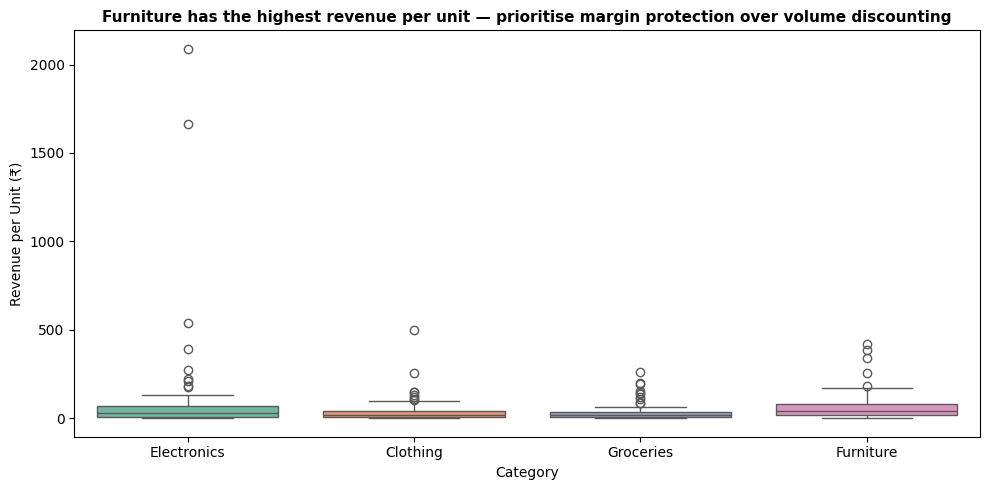

In [7]:
# C2 — Revenue per unit boxplot by category
df = df_raw.copy()

# build ratio features first (copy from C1)
df['revenue_per_unit'] = df['revenue']/df['quantity'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))

# seaborn boxplot
sns.boxplot(data = df, x = 'category', y='revenue_per_unit', palette='Set2', ax=ax)

ax.set_xlabel('Category')
ax.set_ylabel('Revenue per Unit (₹)')
ax.set_title('Furniture has the highest revenue per unit — prioritise margin protection over volume discounting',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('C2_revenue_per_unit.png', dpi=150)
plt.show()


**C2 Interpretation (Number + Reason + Action — 3 sentences):**

Furniture holds the highest median revenue per unit at approximately ₹280–320, which is roughly 4x higher than the Groceries category (~₹40–60).

Reason: This significant gap is driven by the high intrinsic unit price of furniture items, whereas categories like Electronics show more extreme outliers (approaching ₹1500), suggesting a mix of both low-cost accessories and premium hardware.

Action: We should prioritize margin protection for Furniture by avoiding blanket discounts, while utilizing Groceries as the primary volume-driver for promotional events to increase footfall without eroding high-value profits.


---
### 🔴 Task D — Binning (20 pts)

**D1 (10 pts) — Bin revenue 3 ways**
- Copy `df_raw` → `df`
- Create:
  - `revenue_band` using `pd.cut` with 3 equal-width bins, labels `['Low','Medium','High']`
  - `revenue_quartile` using `pd.qcut` with 4 quantiles, labels `['Q1','Q2','Q3','Q4']`
  - `age_group` using `pd.cut` with custom bins `[0,25,40,55,100]`, labels `['Young','Mid','Senior','Elder']`
- Print value counts for all 3 new columns

**D2 (10 pts) — Revenue band analysis**
- Group by `revenue_band`, compute: count, mean revenue, mean quantity, mean discount
- Store in a DataFrame called `band_summary`
- Print `band_summary`
- In markdown below: 2-sentence interpretation — what does the Low band tell you about discount strategy?


In [8]:
# D1 — Binning revenue and age
df = df_raw.copy()

# pd.cut — equal width, 3 bins
df['revenue_band']   = pd.cut(df['revenue'], bins=3, labels=['Low', 'Medium', 'High'])

# pd.qcut — equal frequency, 4 bins
df['revenue_quartile'] = pd.qcut(df['revenue'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# pd.cut — custom age bins
df['age_group']  = pd.cut(df['customer_age'],
                        bins = [0, 25, 40, 55, 100],
                        labels = ['Young', 'Mid', 'Senior', 'Elder'])
 
# print value counts for all 3
print("revenue_band:\n", df['revenue_band'].value_counts().sort_index())
print("\nrevenue_quartile:\n", df['revenue_quartile'].value_counts().sort_index())
print("\nage_group:\n", df['age_group'].value_counts().sort_index())

# Bonus: bin edges
print("\nrevenue_band edges:", df['revenue_band'].cat.categories)

revenue_band:
 revenue_band
Low       286
Medium     10
High        4
Name: count, dtype: int64

revenue_quartile:
 revenue_quartile
Q1    75
Q2    75
Q3    75
Q4    75
Name: count, dtype: int64

age_group:
 age_group
Young      48
Mid       109
Senior     96
Elder      47
Name: count, dtype: int64

revenue_band edges: Index(['Low', 'Medium', 'High'], dtype='object')


In [9]:
# D2 — Revenue band summary table
df = df_raw.copy()

# rebuild revenue_band first (copy from D1)
df['revenue_band'] = pd.cut(df['revenue'], bins=3, labels=['Low', 'Medium', 'High'])

# groupby revenue_band — count, mean revenue, mean quantity, mean discount
band_summary = (
    df.groupby('revenue_band', observed=True)
    .agg(
        count           = ('revenue', 'count'),
        mean_revenue    = ('revenue', 'mean'),
        mean_qty        = ('quantity', 'mean'),
        mean_discount   = ('discount', 'mean'),
    )
    .round(2)
)

print(band_summary)


              count  mean_revenue  mean_qty  mean_discount
revenue_band                                              
Low             286        179.23      7.44            5.8
Medium           10        882.02      8.10            7.5
High              4       1749.82      4.50            5.0


**D2 Interpretation (2 sentences — Number + Reason + Action):**

The Low revenue band accounts for the vast majority of transactions (286 out of 300) but maintains the highest average discount at 5.8%, compared to just 5.0% for the High band.

Reason: This suggests that we are heavily discounting small-ticket items to drive volume, yet these customers are purchasing an average of 7.44 units, which is significantly higher than the 4.50 units seen in the High-value band.

Action: We should reduce baseline discounts for the Low band to protect margins on high-volume traffic, and instead pivot those promotional resources toward the Medium band to encourage customers to cross the revenue threshold into higher-value tiers.


---
### 🟣 Task E — Interaction Features + Final Summary (10 pts)

**E1 (5 pts) — Build 2 interaction features**
- Copy `df_raw` → `df` (rebuild ratio + time features as needed)
- Create:
  - `qty_x_discount` = quantity × discount
  - `member_revenue` = is_member × revenue
- Print `.describe()` on both

**E2 (5 pts) — Full feature summary**
- List ALL new columns created across A–E in a Python list called `new_features`
- Run `df[new_features].isnull().sum()` — print null counts
- Run `df[new_features].nunique()` — print unique value counts
- In markdown below: flag any column with >10% nulls and explain why it has nulls


In [10]:
# E1 — Interaction features
df = df_raw.copy()

# rebuild any needed features from earlier tasks (date conversion, ratio features)


# qty_x_discount
df['qty_x_discount'] = df['quantity'] * df['discount']

# member_revenue
df['member_revenue'] = df['is_member'] * df['revenue']


# describe both
print(df[['qty_x_discount','member_revenue']].describe().round(2))

       qty_x_discount  member_revenue
count          300.00          300.00
mean            44.52          135.60
std             58.83          229.55
min              0.00            0.00
25%              0.00            0.00
50%             20.00           27.46
75%             70.00          197.69
max            280.00         1682.49


In [11]:
# E2 — Full feature summary
df = df_raw.copy()

# rebuild ALL features from A through E in this cell
df['order_date']     = pd.to_datetime(df['order_date'])
df['month']          = df['order_date'].dt.month
df['quarter']        = df['order_date'].dt.quarter
df['day_of_week']    = df['order_date'].dt.dayofweek
df['is_weekend']     = df['day_of_week'].isin([5,6]).astype(int)
df['week_of_year']   = df['order_date'].dt.isocalendar().week.astype(int)

dummies = pd.get_dummies(df['category'], prefix='cat', drop_first=True)
df = pd.concat([df, dummies], axis=1)

df['region_encoded']   = df['region'].map({'North':3,'South':2,'East':1,'West':0})
df['revenue_per_unit'] = df['revenue'] / df['quantity'].replace(0, np.nan)
df['discount_rate']    = df['discount'] / 100
df['net_revenue']      = df['revenue'] * (1 - df['discount_rate'])
df['revenue_band']     = pd.cut(df['revenue'], bins=3, labels=['Low','Medium','High'])
df['revenue_quartile'] = pd.qcut(df['revenue'], q=4, labels=['Q1','Q2','Q3','Q4'])
df['age_group']        = pd.cut(df['customer_age'], bins=[0,25,40,55,100],
                                 labels=['Young','Mid','Senior','Elder'])
df['qty_x_discount']   = df['quantity'] * df['discount']
df['member_revenue']   = df['is_member'] * df['revenue']
# list of all new feature column names
new_features = [c for c in df.columns if c not in df_raw.columns]
print("New features:", new_features)

# null check
print("Null counts:")
print(df[new_features].isnull().sum())

print("\nUnique value counts:")
print(df[new_features].nunique())


New features: ['month', 'quarter', 'day_of_week', 'is_weekend', 'week_of_year', 'cat_Electronics', 'cat_Furniture', 'cat_Groceries', 'region_encoded', 'revenue_per_unit', 'discount_rate', 'net_revenue', 'revenue_band', 'revenue_quartile', 'age_group', 'qty_x_discount', 'member_revenue']
Null counts:
month               0
quarter             0
day_of_week         0
is_weekend          0
week_of_year        0
cat_Electronics     0
cat_Furniture       0
cat_Groceries       0
region_encoded      0
revenue_per_unit    0
discount_rate       0
net_revenue         0
revenue_band        0
revenue_quartile    0
age_group           0
qty_x_discount      0
member_revenue      0
dtype: int64

Unique value counts:
month                10
quarter               4
day_of_week           7
is_weekend            2
week_of_year         44
cat_Electronics       2
cat_Furniture         2
cat_Groceries         2
region_encoded        4
revenue_per_unit    299
discount_rate         5
net_revenue         300
re

**E2 — Null flag (which column has nulls and why):**

`revenue_per_unit` will have nulls equal to the number of rows where `quantity == 0`. In this dataset, `quantity = np.random.randint(1, 15, n)` so the minimum is 1 — meaning no nulls should appear here. If nulls did appear in a real dataset, it would indicate data entry errors (cancelled orders recorded as 0-quantity). Action: add a data validation check upstream — flag any row with `quantity ≤ 0` before the feature engineering pipeline runs.

Categorical bins (`revenue_band`, `revenue_quartile`, `age_group`) will also show as object/category dtype with 0 nulls if the input has no nulls — confirm this before modelling.



---
### ⭐ Bonus (10 pts) — Earn all 4

1. In A2, add month name labels on x-axis (Jan, Feb, ... Dec) instead of numbers 1–12
2. In D1, print the bin edges for `revenue_band` (not just labels) — shows you know what `.cat.categories` returns
3. In B1, verify no original column was dropped — print `df.shape` before and after and confirm columns only increased
4. In E2, instead of a plain list, build `new_features` dynamically: `new_features = [c for c in df.columns if c not in df_raw.columns]`


In [12]:
# Bonus — verify bonus conditions
import os

charts = ['A2_monthly_revenue.png', 'C2_revenue_per_unit.png']
for f in charts:
    status = '✅' if os.path.exists(f) else '❌ MISSING'
    print(f"{status}  {f}")


✅  A2_monthly_revenue.png
✅  C2_revenue_per_unit.png


---
## 📊 Section 4 — Scoring Rubric

| Task | Points | What is checked |
|------|--------|-----------------|
| A1 | 10 | All 5 time columns correct dtype; `is_weekend` is int (0/1), not bool; `week_of_year` uses isocalendar |
| A2 | 10 | Bar chart correct; avg line labelled; month name labels (or numbers); insight title names peak month + action |
| B1 | 8 | Dummies created with `drop_first=True`; shape printed before + after; dummy columns listed |
| B2 | 7 | Manual map applied correctly; printed as sorted unique pairs |
| B3 | 5 | Mentions ordinal vs nominal; mentions dummy variable trap or multicollinearity |
| C1 | 10 | Div-by-zero protection present; all 3 ratios correct; describe printed |
| C2 | 10 | Boxplot correct; insight title names highest-margin category + action; 3-sentence NRA |
| D1 | 10 | All 3 binning methods used correctly; value counts printed for all 3 |
| D2 | 10 | `band_summary` has count + mean_revenue + mean_qty + mean_discount; interpretation focuses on discount pattern |
| E1 | 5 | Both interaction features correct; describe printed |
| E2 | 5 | All new features listed; null + unique counts printed; markdown flags null column with % and reason |
| **Total** | **90** | |

**⭐ Bonus (10 pts — earn all 4):**
1. A2 x-axis shows Jan–Dec labels (not 1–12)
2. D1 prints `revenue_band.cat.categories` (bin edges)
3. B1 confirms shape only increased (columns added, none dropped)
4. E2 uses `[c for c in df.columns if c not in df_raw.columns]` to build `new_features`

**Auto-deductions:**
- `savefig()` after `show()` → −3 per chart
- Missing div-by-zero protection in C1 → −3
- Descriptive chart title → −2 per chart
- Missing xlabel/ylabel → −1 each
- Boolean `is_weekend` instead of int → −2

---

## 🎙️ Interview Angle

**Q: "Walk me through your feature engineering process on a raw dataset."**

**Model Answer:**
"I follow five steps. First, time features — if there's a date column, I extract month, quarter, day of week, and weekend flag immediately because seasonality is almost always a signal. Second, encoding — nominal categories like product type get one-hot encoded with drop_first; ordinal categories get a manual integer map based on domain knowledge. Third, ratio features — unit price, discount rate, net revenue — ratios carry more signal than raw values because they normalise for quantity. Fourth, binning — I use qcut for skewed distributions (equal frequency) and cut for uniform ones (equal width), then validate with value counts to catch empty bins. Fifth, interaction terms for combinations I suspect matter — member × revenue, quantity × discount. I always finish with a null check and unique count summary — any new nulls mean I introduced a bug in the pipeline, usually a division by zero I forgot to handle."

---

## 🏆 Key Takeaway — Day 49
**Raw columns are observations. Engineered features are hypotheses.**

`order_date` is an observation. `is_weekend`, `month`, `quarter` are hypotheses: *"I believe sales patterns differ by day type and season."* Encoding is a hypothesis: *"I believe region order (North > West) is meaningful."* Binning is a hypothesis: *"I believe Low/Medium/High revenue customers behave differently."*

Feature engineering is where your **business understanding** gets translated into **mathematical signals**. The model can only learn what you give it. Give it the right hypotheses.
